# Behavioural Gold — descriptives, relations, interactions

Walter's folder. Not Katerina's notebook.

Gold is `outputs/gold/` (54 people, 270 condition rows, 216 ads). Rebuild with `python analysis/walter/behavioural/build_gold.py`.

**Frozen composites** (planned, \(8-x\) on reverse items):

- `credibility` = mean(`llm_reliable`, \(8-\)`llm_false`, \(8-\)`llm_made_up`)
- `manipulation` = mean(`behaviour_pushing`, `behaviour_manipulate`) — **both items kept**
- `notice` = mean(`notice_brands`, `notice_sponsored`) — **both items kept**
- `trust` = `personality_trust` (single item)

Helpfulness / convincingness / relevance / neutrality stay secondary. Raw `llm_*` items are on the condition table for appendix descriptives. Do not drop items to hunt \(p\).

Person is the unit. Planned \(D\) weights match EEG Dataset A: any-ad − no-ad, implicit − explicit, early − late. Holm is the Holm-adjusted paired \(t\), within outcome. Wilcoxon \(p\) is raw.

Combo scatters (lab \(n=18\)) are associations, not mediation.

In [1]:
from pathlib import Path
import sys

import pandas as pd
from IPython.display import Image, display

HERE = Path.cwd().resolve()
if not (HERE / "build_gold.py").exists():
    HERE = HERE / "analysis/walter/behavioural"
if str(HERE) not in sys.path:
    sys.path.insert(0, str(HERE))

from run_eda import run, GOLD, OUT, PRIMARY, ITEM_PAIR

run()
pd.set_option("display.max_columns", 80)
pd.set_option("display.width", 140)
print("Gold", GOLD)
print("EDA ", OUT)

Gold /home/wtroi/MasterThesis-RAG-RecSys/analysis/walter/behavioural/outputs/gold
EDA  /home/wtroi/MasterThesis-RAG-RecSys/analysis/walter/behavioural/outputs/eda


## Gold grain

| File | Rows |
|---|---|
| `id_map.csv` / `person_features.csv` | 54 |
| `condition_features.csv` | 270 |
| `advertisement_features.csv` | 216 |
| `contrast_scores.csv` | 54 (behavioural \(D\)) |
| `combo_condition_lab.csv` | 90 |
| `combo_contrast_lab.csv` | 18 |

In [2]:
gold = {
    name: pd.read_csv(GOLD / f"{name}.csv")
    for name in (
        "id_map",
        "person_features",
        "condition_features",
        "advertisement_features",
        "contrast_scores",
        "combo_condition_lab",
        "combo_contrast_lab",
    )
}
for name, frame in gold.items():
    print(f"{name:28s} {frame.shape[0]:4d} × {frame.shape[1]:3d}")
assert len(gold["id_map"]) == 54
assert len(gold["condition_features"]) == 270
assert gold["condition_features"]["n_ad_clicked"].eq(0).all()

id_map                         54 ×  10
person_features                54 ×  16
condition_features            270 ×  69
advertisement_features        216 ×  73
contrast_scores                54 × 139
combo_condition_lab            90 × 115
combo_contrast_lab             18 × 139


## Condition descriptives

Means (SD) on the 1–7 scale. Manipulation and notice sit next to the two items that form them.

,label,n,trust_mean,trust_sd,credibility_mean,credibility_sd,manipulation_mean,manipulation_sd,notice_mean,notice_sd,behaviour_pushing_mean,behaviour_pushing_sd,behaviour_manipulate_mean,behaviour_manipulate_sd,notice_brands_mean,notice_brands_sd,notice_sponsored_mean,notice_sponsored_sd
0,no ad,54,5.37,1.63,6.04,1.15,2.73,1.97,2.96,1.63,2.69,1.97,2.78,2.16,4.07,2.48,1.85,1.62
1,implicit early,54,4.93,1.80,5.69,1.35,3.94,2.10,4.56,1.89,4.07,2.42,3.80,2.10,5.43,2.12,3.70,2.51
2,implicit late,54,5.28,1.58,6.04,1.09,3.45,1.98,4.36,1.89,3.44,2.13,3.46,2.08,5.30,2.22,3.43,2.43
3,explicit early,54,4.69,1.91,5.78,1.30,4.65,1.95,5.77,1.74,4.96,2.16,4.33,2.12,5.87,1.99,5.67,2.06
4,explicit late,54,5.22,1.76,6.08,0.93,3.97,2.06,5.45,1.94,4.28,2.27,3.67,2.15,5.65,2.08,5.26,2.31


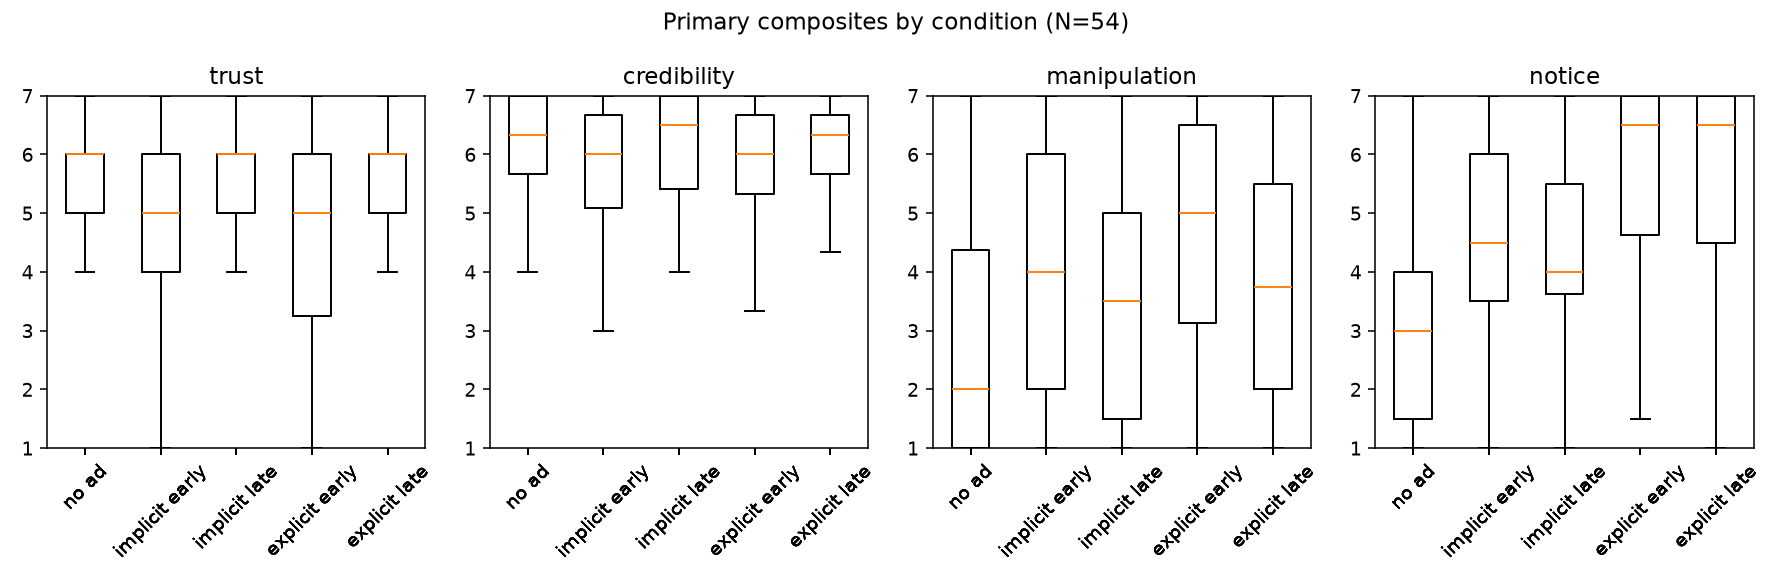

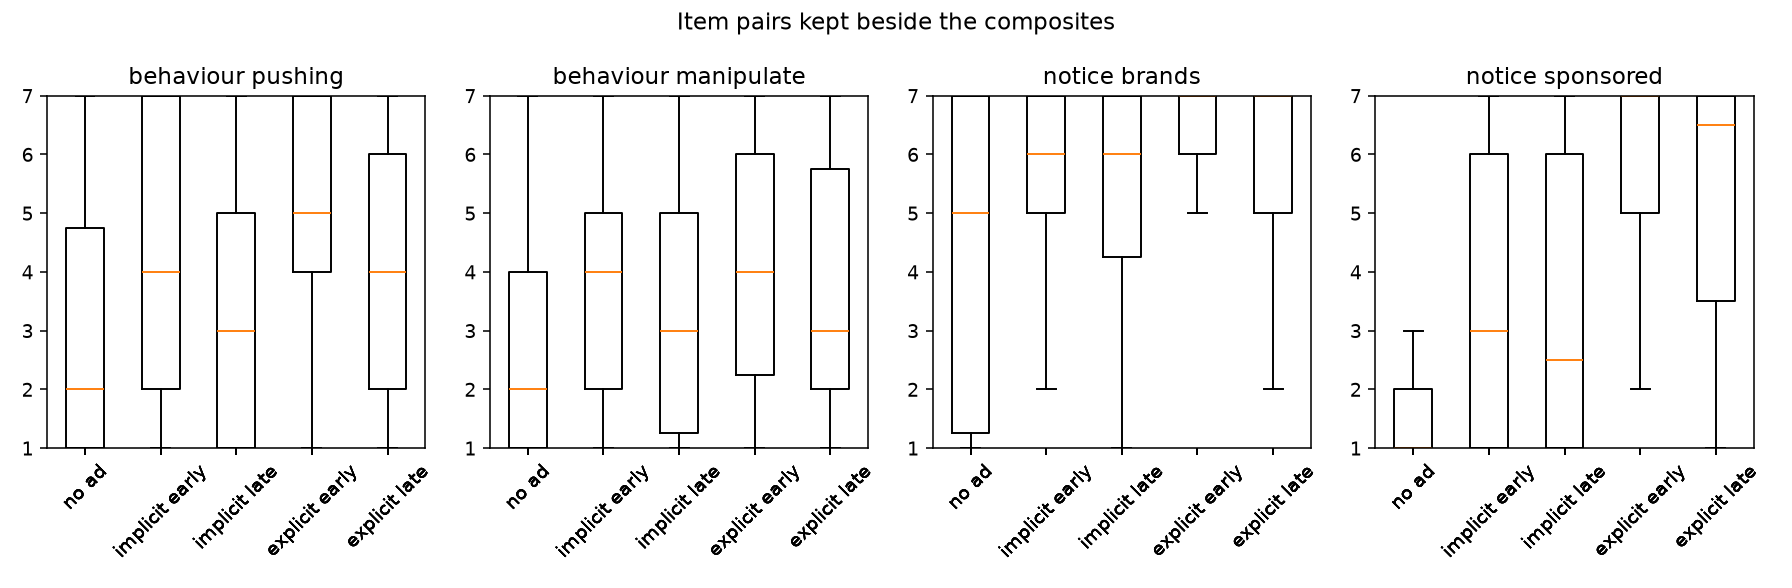

In [3]:
desc = pd.read_csv(OUT / "condition_descriptives.csv")
keep = ["label", "n"]
for col in list(PRIMARY) + list(ITEM_PAIR):
    keep.extend([f"{col}_mean", f"{col}_sd"])
display(desc[keep].round(2))
display(Image(OUT / "box_primary.png"))
display(Image(OUT / "box_items.png"))

## Format × timing cells

Four ad conditions only (`no_ads` has no format/timing). This is the interaction view, not a second confirmatory family.

In [4]:
cells = pd.read_csv(OUT / "format_timing_cells.csv")
cols = ["presentation", "timing", "n"] + [f"{c}_mean" for c in PRIMARY]
display(cells[cols].round(2))
print("Arm × condition (primary means)")
display(pd.read_csv(OUT / "arm_condition_means.csv").round(2))

,presentation,timing,n,trust_mean,credibility_mean,manipulation_mean,notice_mean
0,explicit,early,54,4.69,5.78,4.65,5.77
1,explicit,late,54,5.22,6.08,3.97,5.45
2,implicit,early,54,4.93,5.69,3.94,4.56
3,implicit,late,54,5.28,6.04,3.45,4.36


Arm × condition (primary means)


,arm,condition,label,n,trust_mean,credibility_mean,manipulation_mean,notice_mean
0,crowd,block_early,explicit early,36,5.00,6.03,4.39,5.76
1,crowd,block_late,explicit late,36,5.39,6.13,3.61,5.54
2,crowd,inline_early,implicit early,36,5.28,5.93,3.82,4.58
3,crowd,inline_late,implicit late,36,5.47,6.17,3.33,4.33
4,crowd,no_ads,no ad,36,5.61,6.11,2.67,3.03
5,lab,block_early,explicit early,18,4.06,5.28,5.17,5.78
6,lab,block_late,explicit late,18,4.89,5.98,4.69,5.28
7,lab,inline_early,implicit early,18,4.22,5.20,4.17,4.53
8,lab,inline_late,implicit late,18,4.89,5.80,3.69,4.42
9,lab,no_ads,no ad,18,4.89,5.89,2.86,2.83


## Planned \(D\) (n = 54)

Same weights as EEG. Holm is within outcome across the three contrasts. Wilcoxon \(p\) is raw. This is the Goal 1 companion table, not an item search.

,outcome,contrast_label,mean,ci95_lo,ci95_hi,p_t,p_holm,p_wilcoxon,dz,holm_sig
0,trust,any ad − no ad,-0.343,-0.714,0.029,0.076,0.153,0.016,-0.246,False
1,trust,implicit − explicit,0.148,-0.198,0.494,0.405,0.405,0.384,0.114,False
2,trust,early − late,-0.444,-0.811,-0.078,0.021,0.063,0.026,-0.324,False
3,credibility,any ad − no ad,-0.140,-0.424,0.143,0.336,0.673,0.040,-0.132,False
4,credibility,implicit − explicit,-0.065,-0.241,0.112,0.475,0.673,0.248,-0.098,False
5,credibility,early − late,-0.330,-0.554,-0.107,0.005,0.016,0.007,-0.394,True
6,manipulation,any ad − no ad,1.271,0.757,1.785,0.000,0.000,0.000,0.660,True
7,manipulation,implicit − explicit,-0.616,-1.128,-0.104,0.022,0.022,0.022,-0.321,True
8,manipulation,early − late,0.579,0.206,0.951,0.004,0.007,0.004,0.414,True
9,notice,any ad − no ad,2.074,1.528,2.620,0.000,0.000,0.000,1.013,True


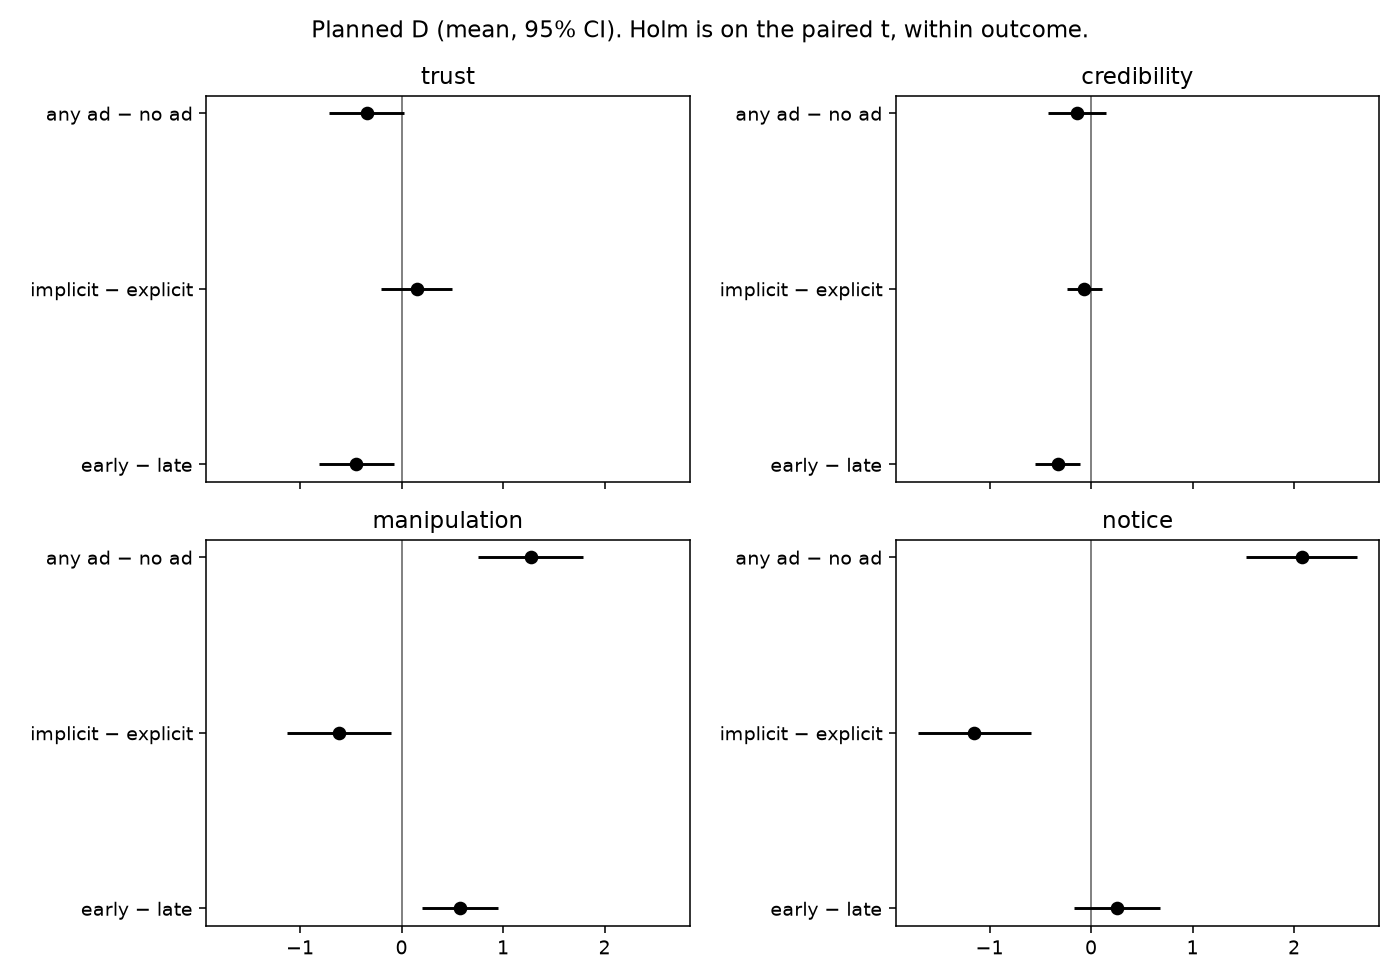

In [5]:
tests = pd.read_csv(OUT / "planned_contrasts.csv")
show = tests.loc[tests["outcome"].isin(list(PRIMARY) + list(ITEM_PAIR))]
display(
    show[
        ["outcome", "contrast_label", "mean", "ci95_lo", "ci95_hi", "p_t", "p_holm", "p_wilcoxon", "dz", "holm_sig"]
    ].round(3)
)
display(Image(OUT / "forest_planned_D.png"))

## Correlations (person means, n = 54)

Spearman. Do not treat 270 condition rows as independent. BFI is also correlated with \(D_{\mathrm{any\ ad}}\) (does personality track the *shift*, not just the level).

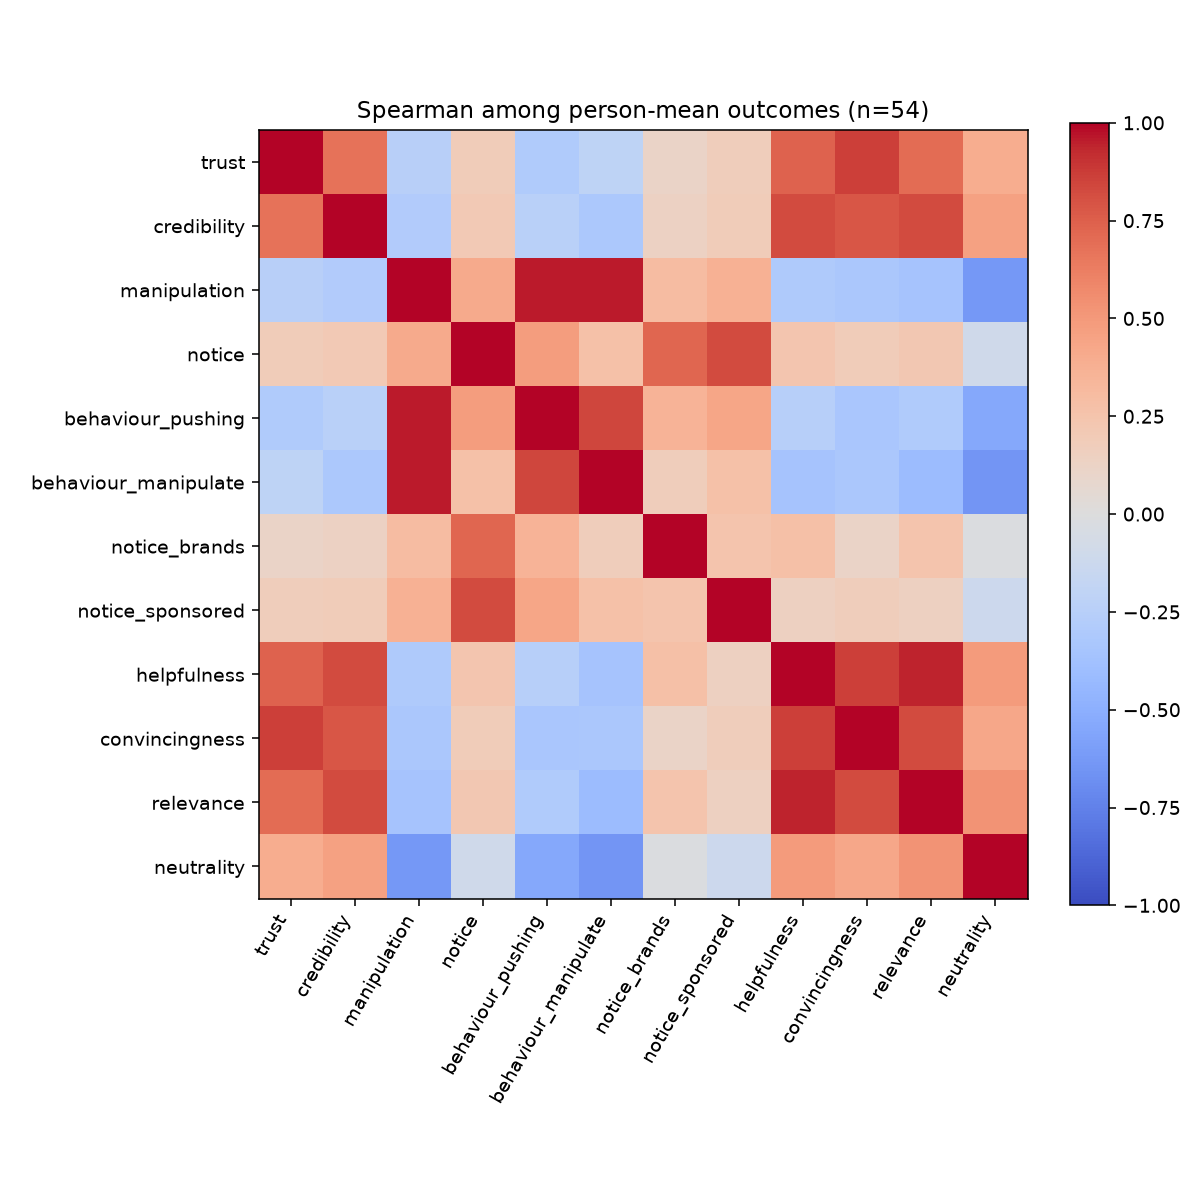

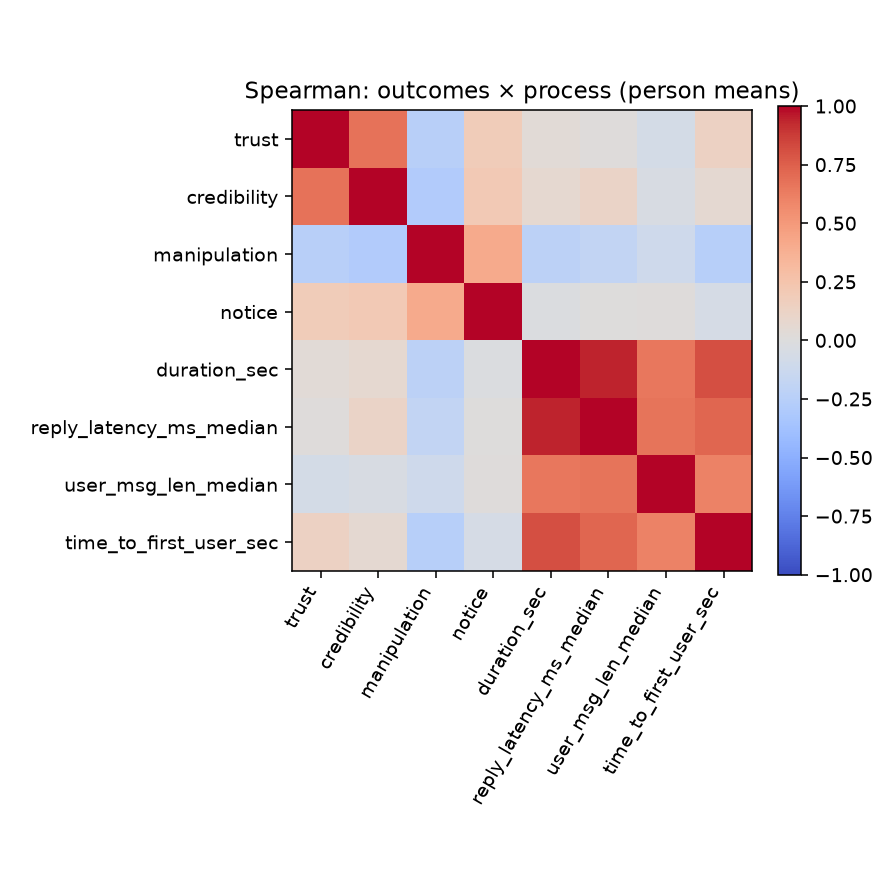

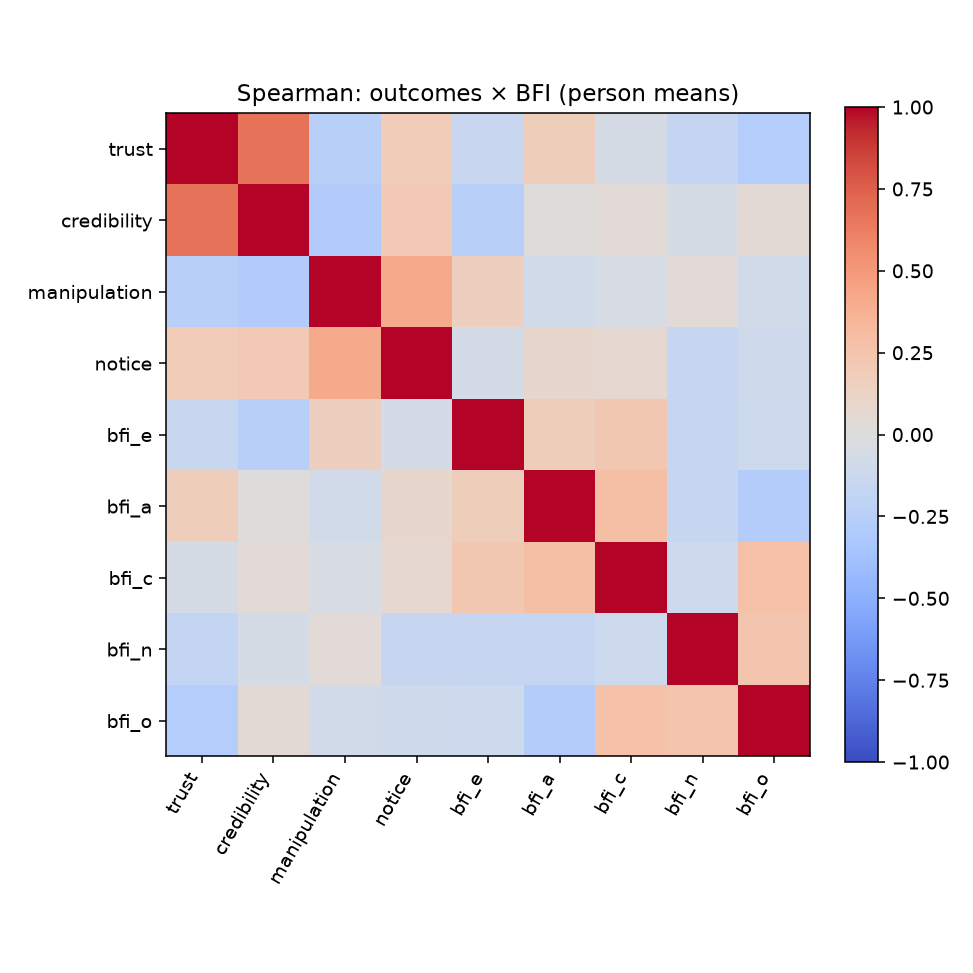

D_any_ad × BFI


,D_trust,D_credibility,D_manipulation,D_notice,bfi_e,bfi_a,bfi_c,bfi_n,bfi_o
D_trust,1.00,0.40,-0.40,-0.09,0.05,-0.01,0.07,-0.17,-0.12
D_credibility,0.40,1.00,-0.26,-0.01,-0.10,-0.05,-0.04,-0.22,-0.32
D_manipulation,-0.40,-0.26,1.00,0.72,0.01,0.04,0.05,-0.01,0.21
D_notice,-0.09,-0.01,0.72,1.00,0.01,0.08,0.21,0.01,0.14
bfi_e,0.05,-0.10,0.01,0.01,1.00,0.17,0.22,-0.15,-0.12
bfi_a,-0.01,-0.05,0.04,0.08,0.17,1.00,0.29,-0.16,-0.28
bfi_c,0.07,-0.04,0.05,0.21,0.22,0.29,1.00,-0.12,0.27
bfi_n,-0.17,-0.22,-0.01,0.01,-0.15,-0.16,-0.12,1.00,0.24
bfi_o,-0.12,-0.32,0.21,0.14,-0.12,-0.28,0.27,0.24,1.00


In [6]:
display(Image(OUT / "heatmap_outcomes.png"))
display(Image(OUT / "heatmap_process.png"))
display(Image(OUT / "heatmap_bfi.png"))
print("D_any_ad × BFI")
display(pd.read_csv(OUT / "spearman_D_any_ad_bfi.csv", index_col=0).round(2))

## Recall (216 ads) and lab associations (n = 18)

Recall has no `no_ads` cell. Lab Spearman is exploratory association on the same \(D\) weights.

In [7]:
display(pd.read_csv(OUT / "recall_descriptives.csv").round(2))
combo = pd.read_csv(OUT / "combo_spearman_lab.csv").sort_values("p")
print("Lowest-p lab associations (exploratory; not a hunt)")
display(combo.head(12).round(3))

,split,level,n,recall_memory_mean,recall_memory_sd,recall_trust_shift_mean,recall_trust_shift_sd
0,condition,block_early,54,6.09,1.39,3.85,2.16
1,condition,block_late,54,5.61,1.89,4.56,2.12
2,condition,inline_early,54,4.35,2.36,4.19,1.85
3,condition,inline_late,54,4.44,2.19,4.46,1.88
4,presentation,explicit,108,5.85,1.67,4.20,2.16
5,presentation,implicit,108,4.40,2.27,4.32,1.86
6,timing,early,108,5.22,2.12,4.02,2.01
7,timing,late,108,5.03,2.12,4.51,1.99


Lowest-p lab associations (exploratory; not a hunt)


,behaviour,eeg,n,spearman_rho,p
351,manipulation__inline_vs_block,eeg_faa__any_ad_vs_no_ads,18,0.698,0.001
275,credibility__early_vs_late,eeg_rel_beta__early_vs_late,18,-0.603,0.008
281,credibility__early_vs_late,eeg_engagement__early_vs_late,18,-0.584,0.011
60,trust__inline_vs_block,eeg_beta__any_ad_vs_no_ads,18,-0.578,0.012
260,credibility__early_vs_late,eeg_delta__early_vs_late,18,0.574,0.013
93,trust__inline_vs_block,eeg_kislov__any_ad_vs_no_ads,18,-0.573,0.013
372,manipulation__inline_vs_block,eeg_rel_gamma__any_ad_vs_no_ads,18,0.569,0.014
495,notice__inline_vs_block,eeg_faa__any_ad_vs_no_ads,18,0.564,0.015
92,trust__inline_vs_block,eeg_pope__early_vs_late,18,0.562,0.015
308,manipulation__any_ad_vs_no_ads,eeg_delta__early_vs_late,18,-0.551,0.018


## Giant correlation matrices (person grain)

Curiosity artefacts, not tests. Spearman over person means (five conditions averaged), blocks separated by lines: surveys · recall · process · BFI · trajectory, and a lab-only version with the 16 EEG \(k=37\) medians. Dots are raw \(p<.05\); the pair count is in the title, so ~5% of dots are noise by construction. Rebuild: `python analysis/walter/behavioural/stats/run_giant_corr.py`.

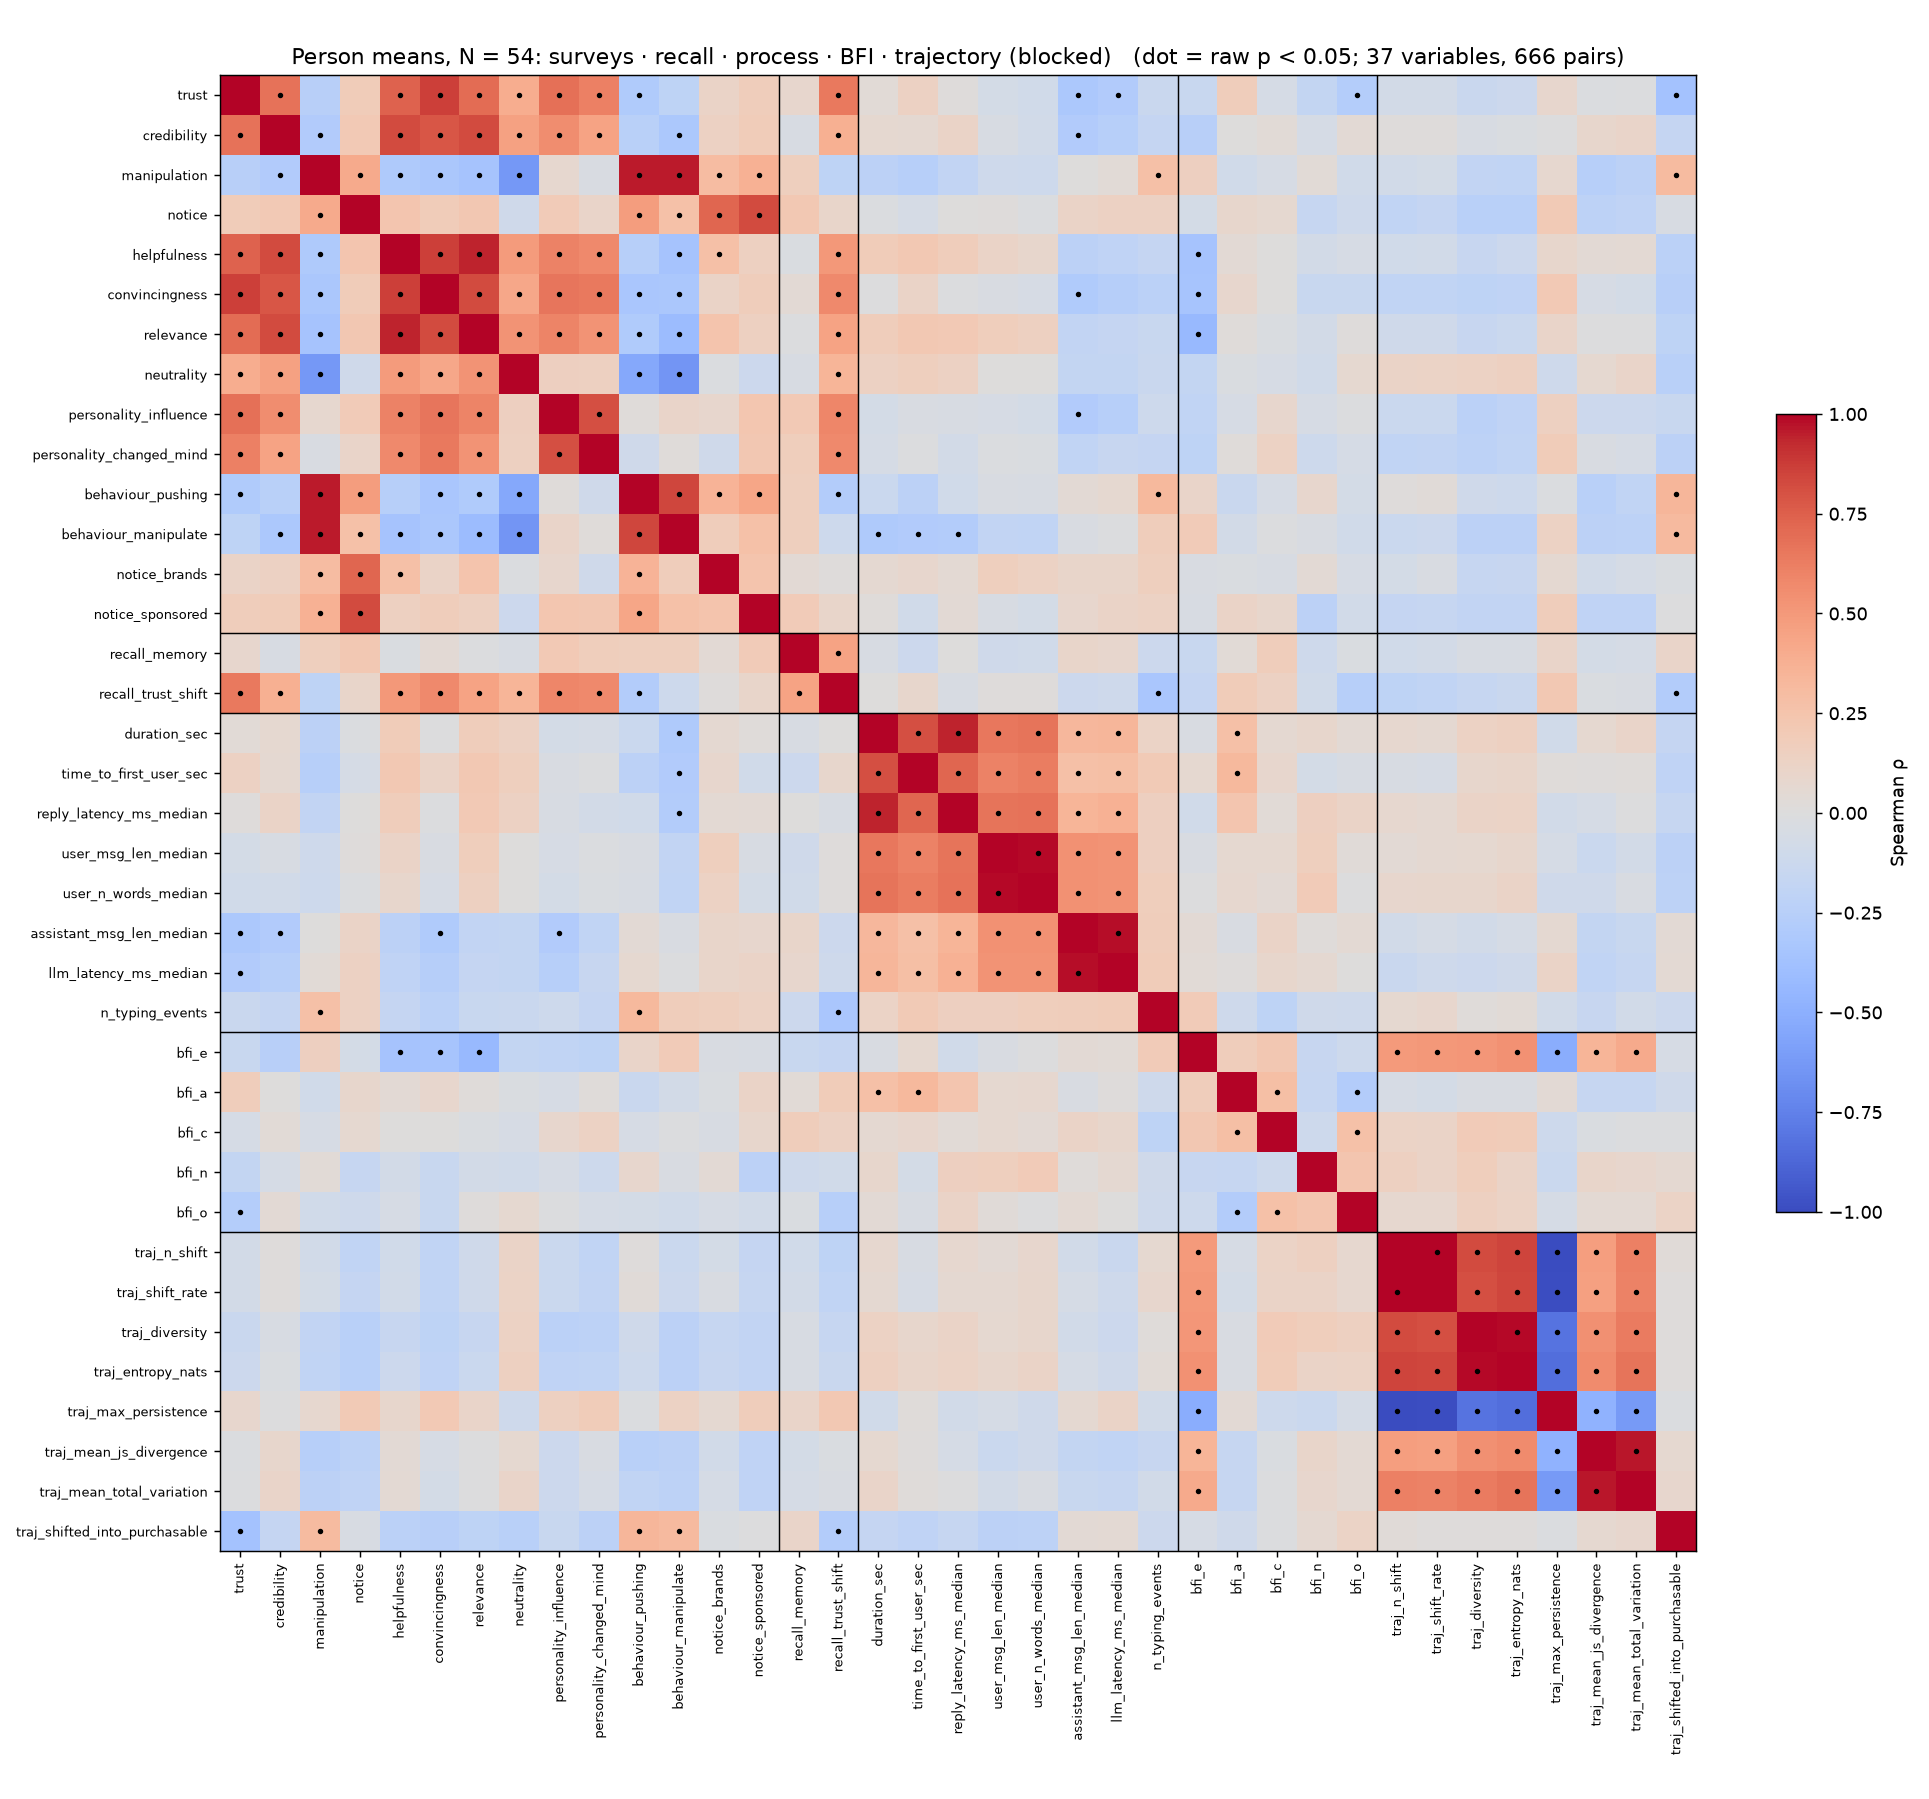

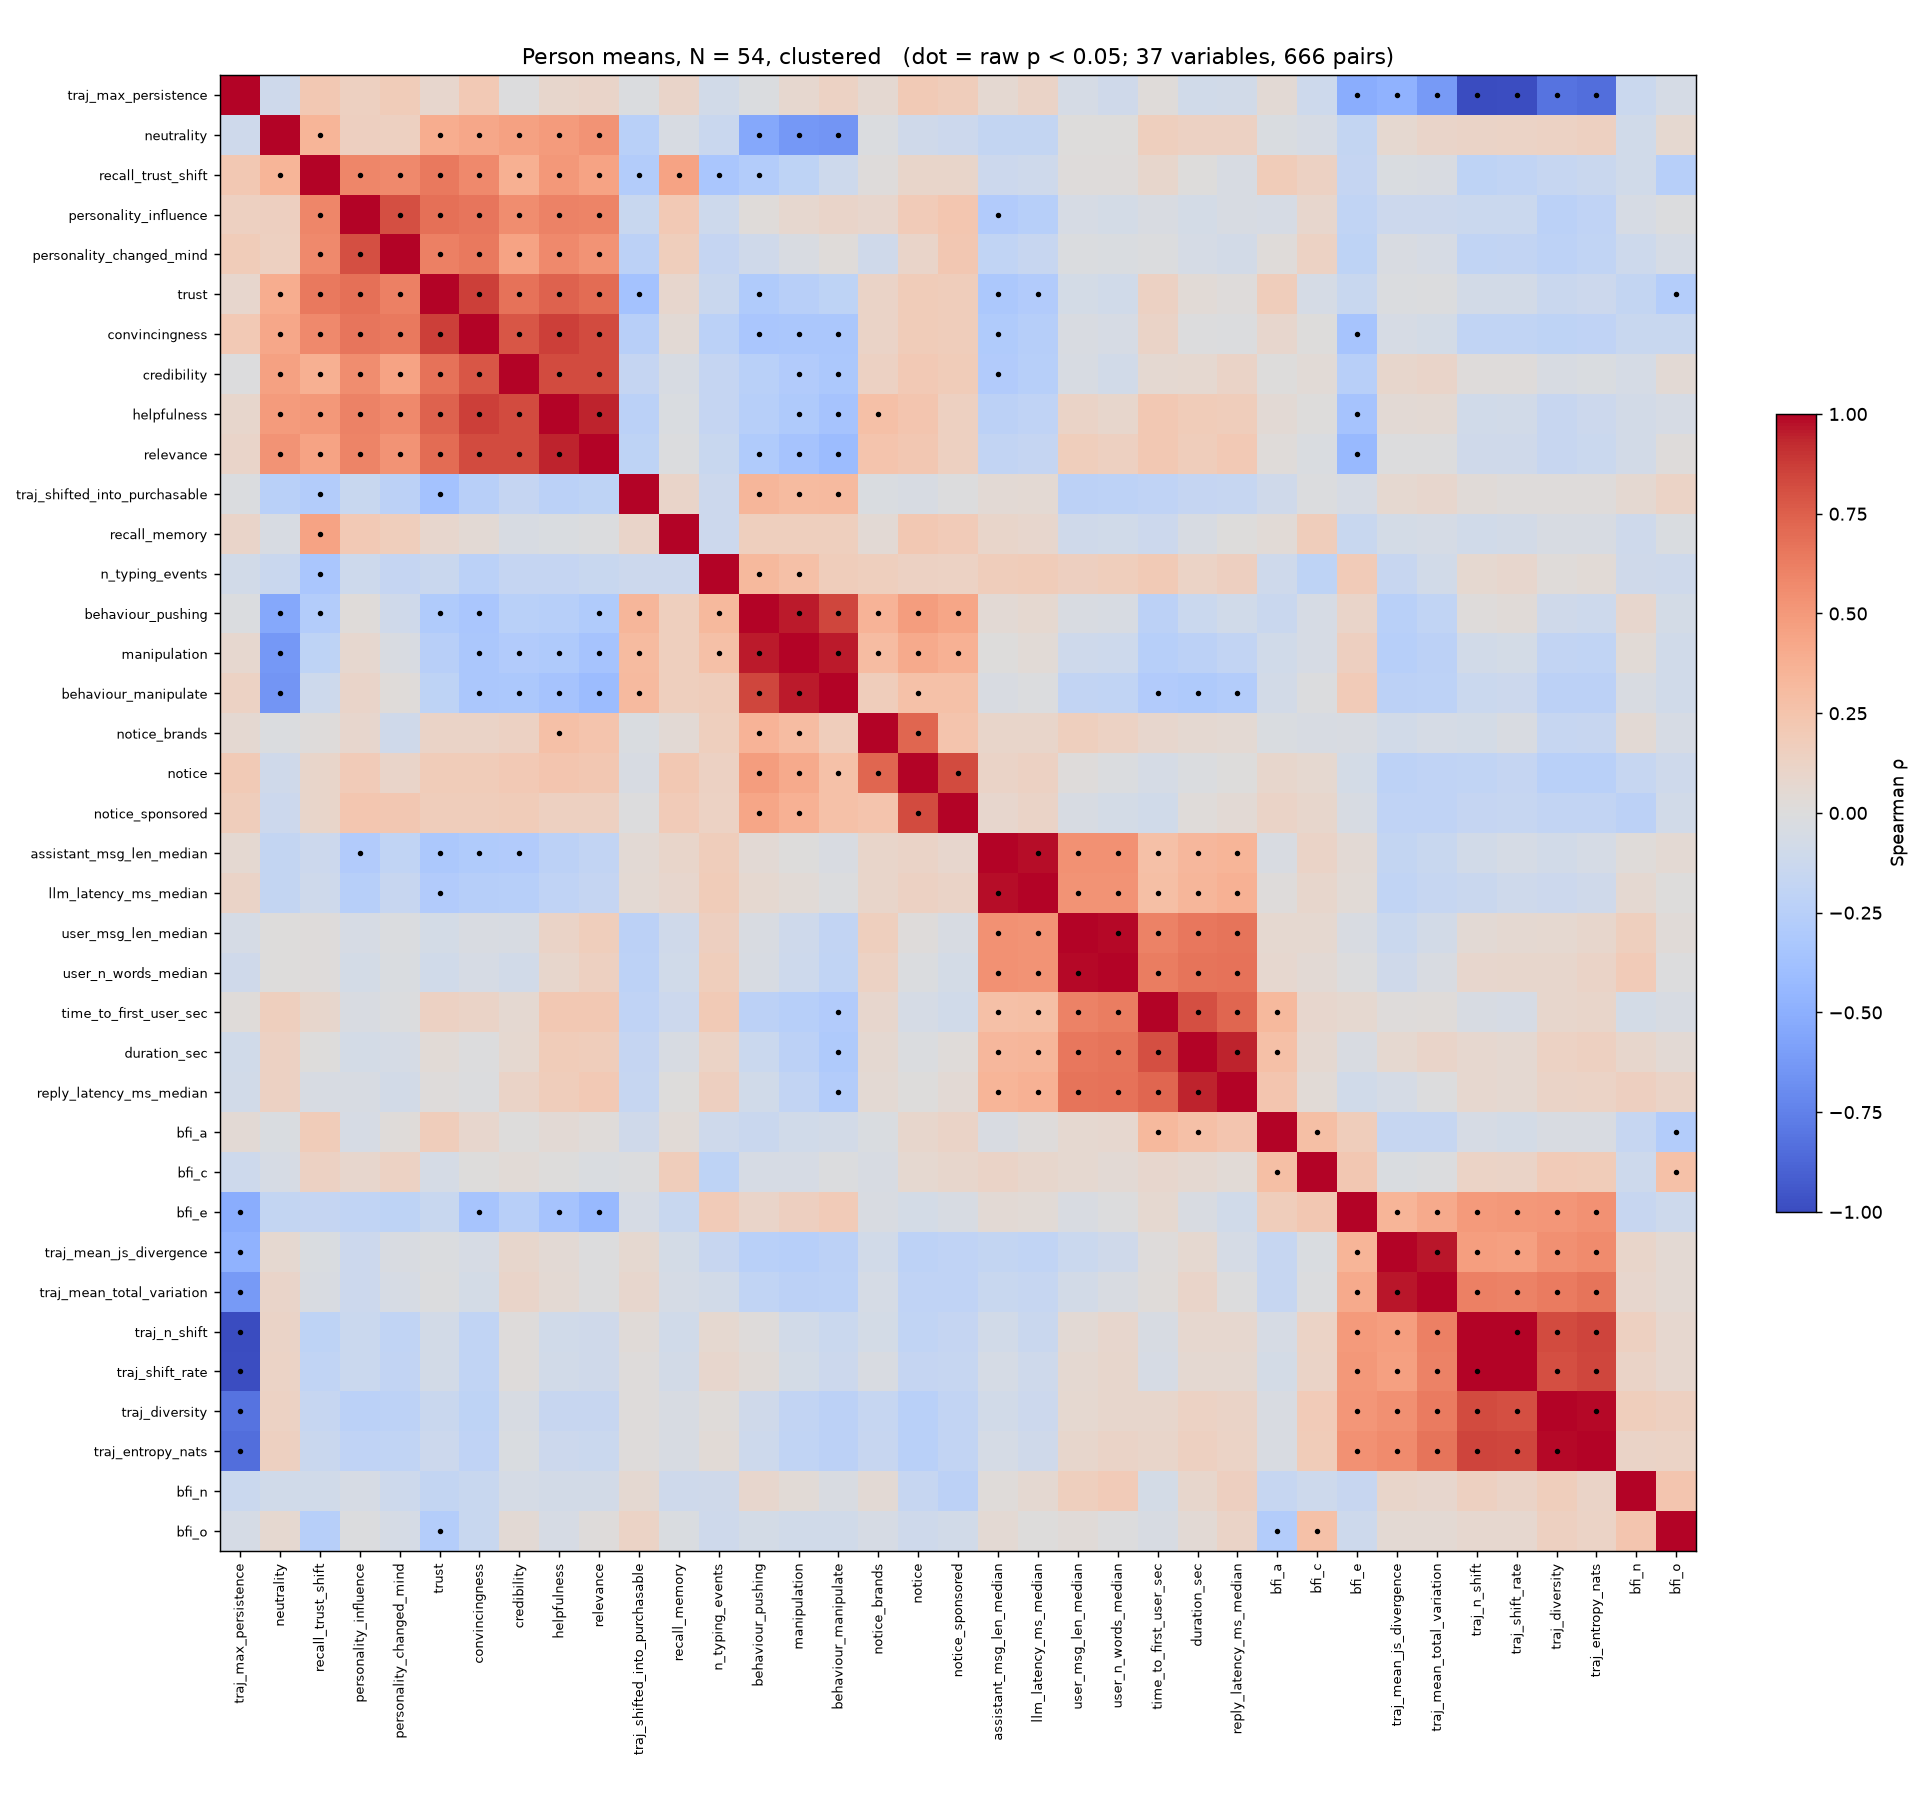

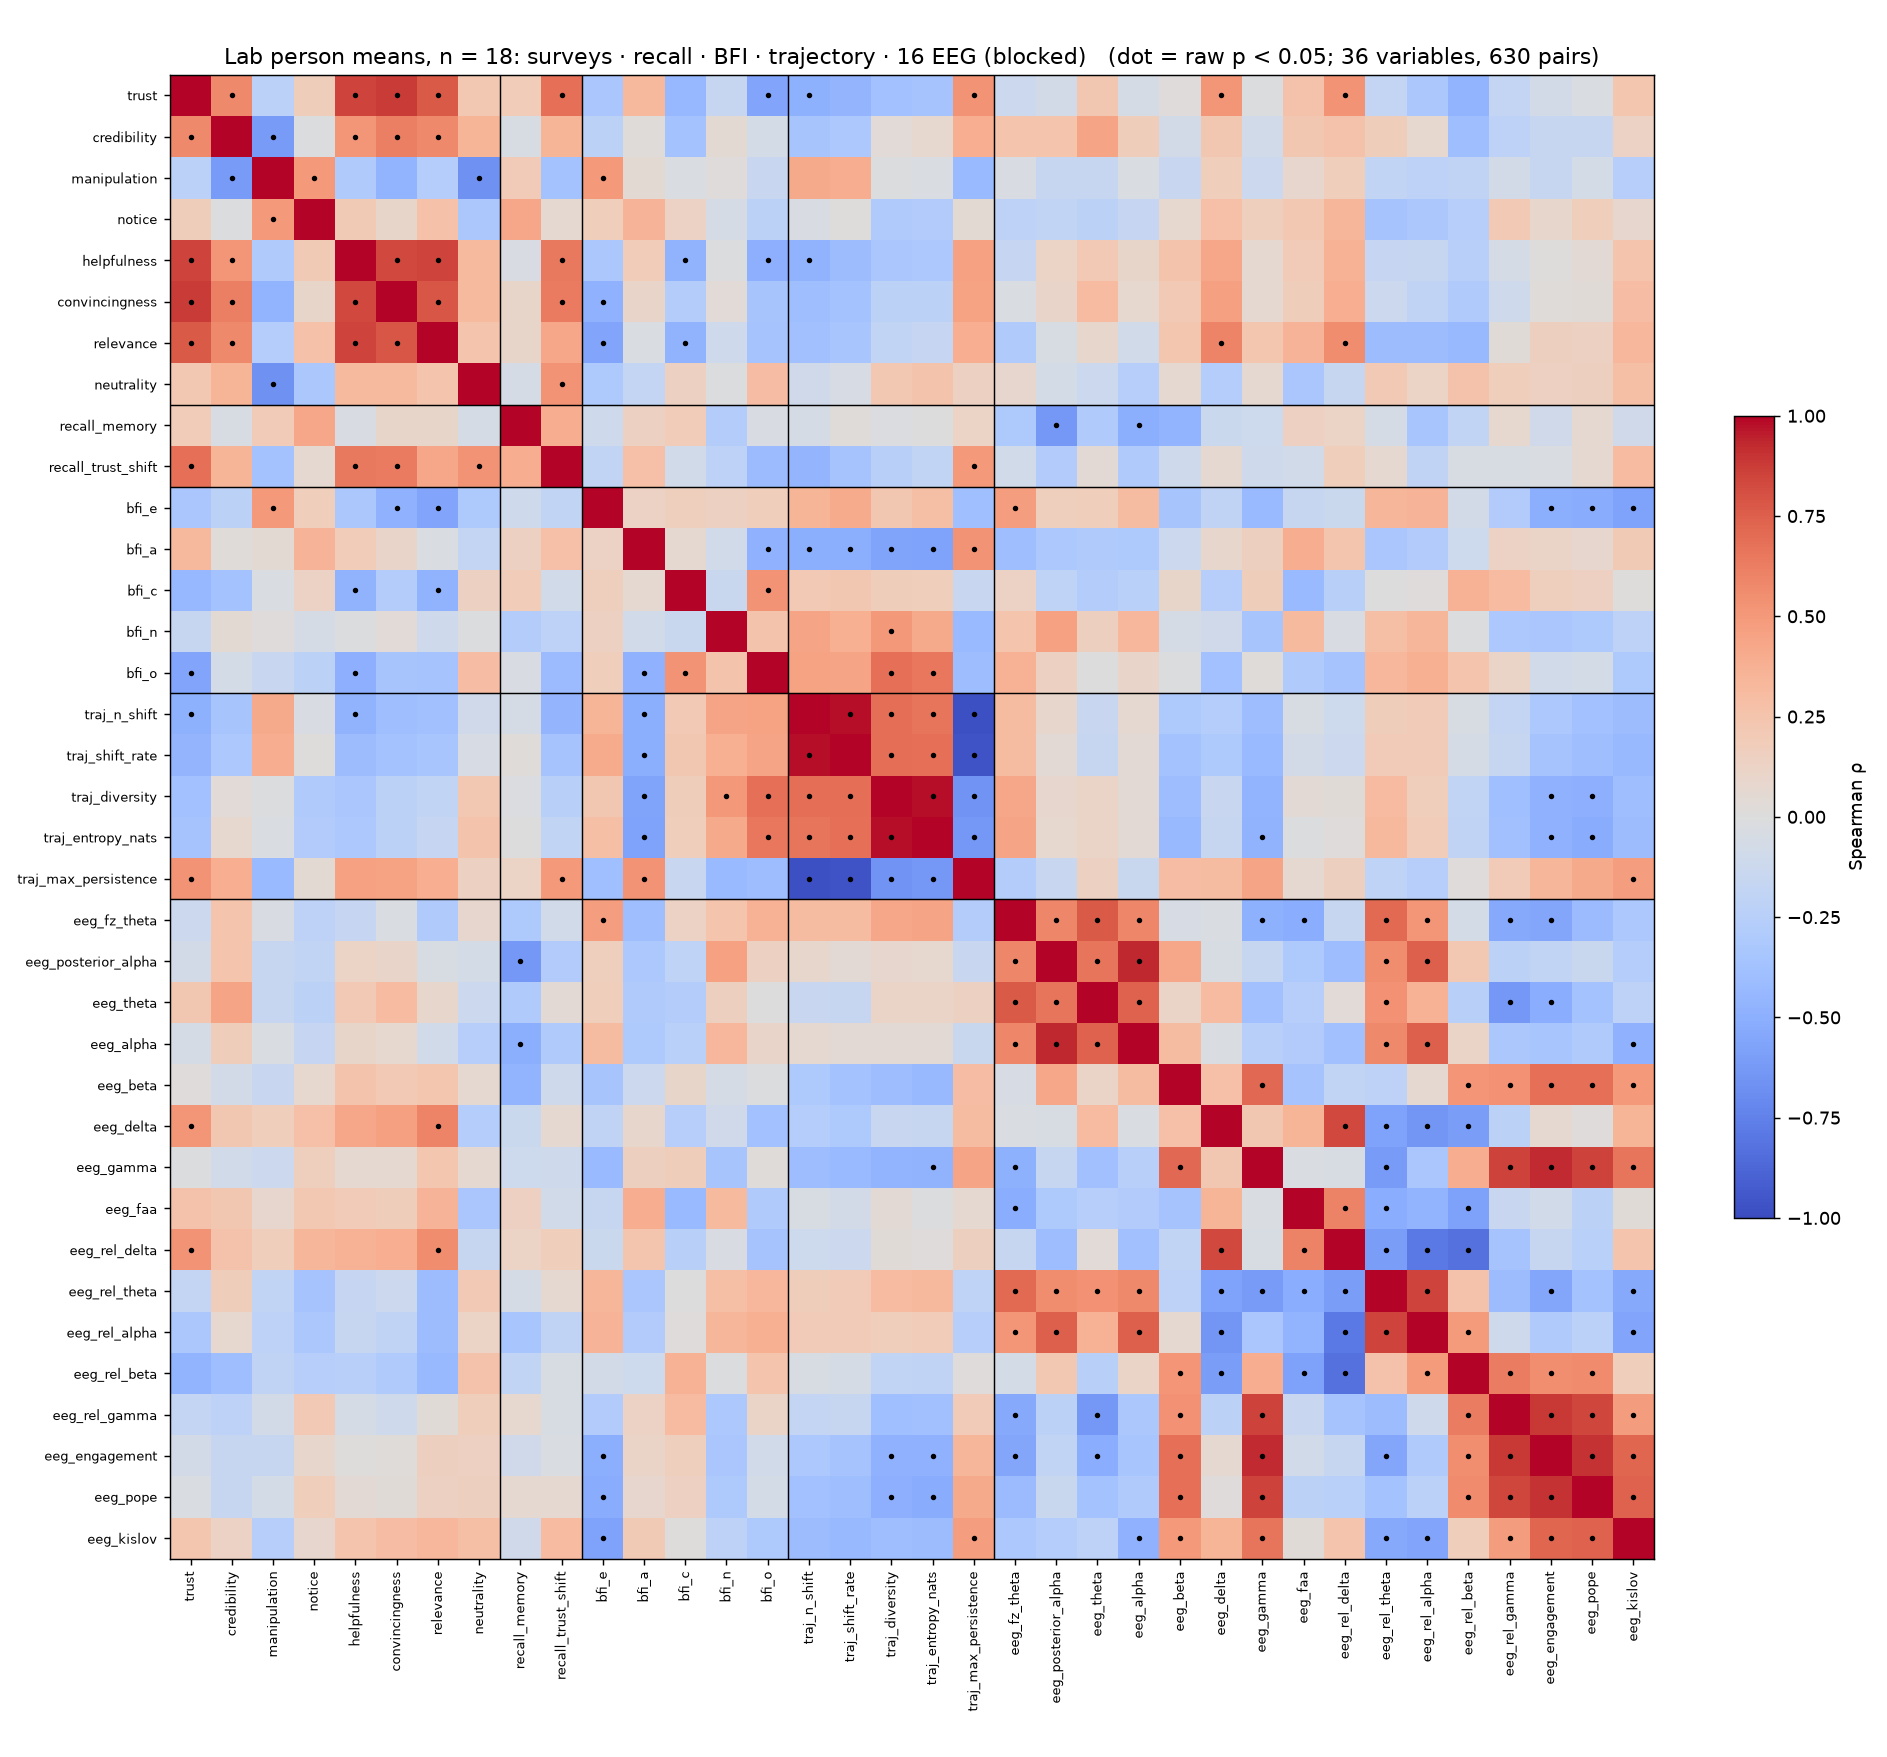

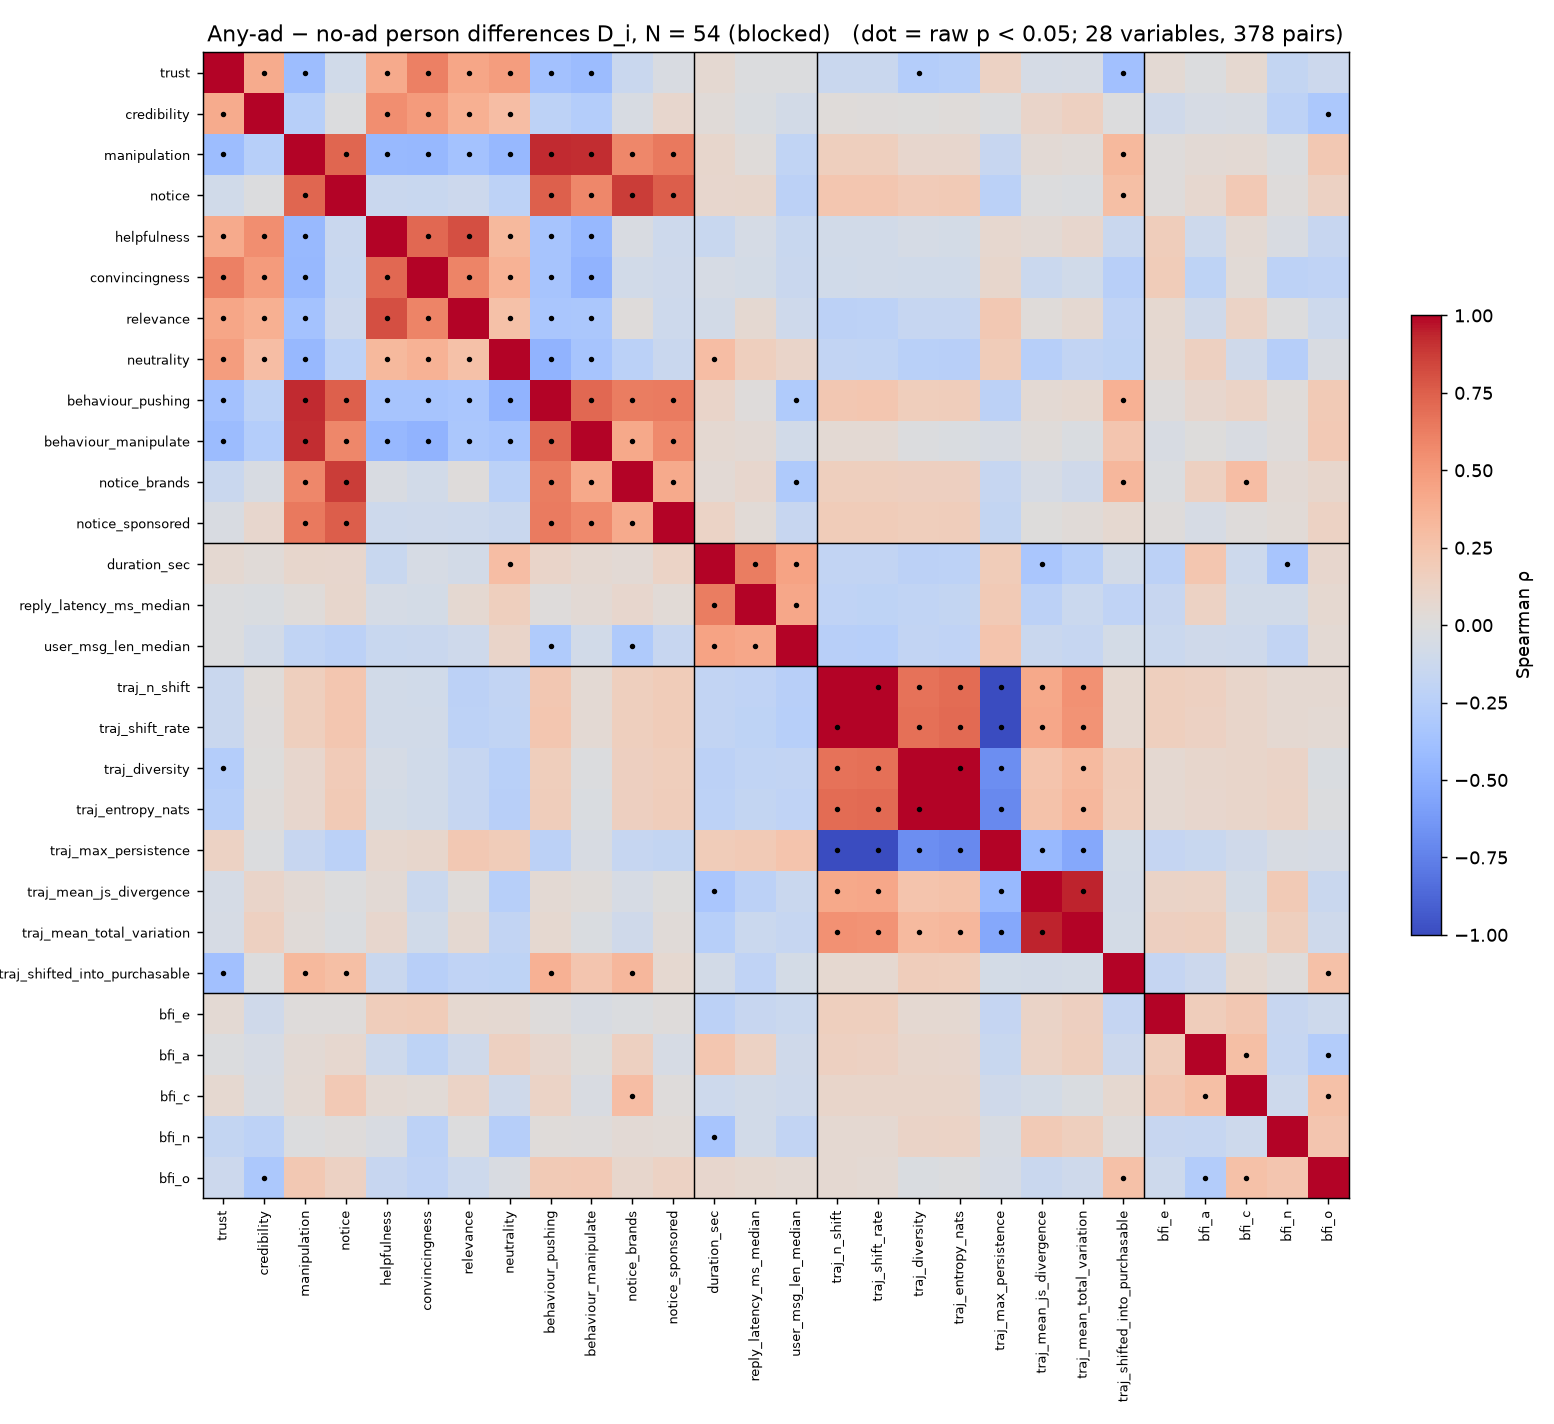

In [8]:
from pathlib import Path
from IPython.display import Image, display
import pandas as pd
EDA = Path(OUT)
for f in ["giant_corr_person_blocked.png", "giant_corr_person_clustered.png", "giant_corr_lab_eeg_blocked.png", "giant_corr_D_any_ad_blocked.png"]:
    display(Image(EDA / f))

## Process variables by condition (descriptive)

Duration, first-message latency, reply latency, message length, typing, conclusion length. In the exploratory sweep none of these moves with condition (0 corrected hits in 349 tests), so this is a manipulation check: ads did not change how people chatted.

In [9]:
pt = pd.read_csv(EDA / "process_by_condition.csv", header=[0, 1], index_col=0)
display(pt)

duration_sec        time_to_first_user_sec        reply_latency_ms_median          user_msg_len_median        \
                       mean    std                   mean    std                    mean      std                mean   std   
no ad                 290.3  165.3                   79.9   52.9                 49542.5  31468.1                94.4  55.4   
implicit early        307.4  177.0                   88.6   76.4                 53204.0  37522.3                89.8  56.5   
implicit late         305.7  179.7                   79.4   70.9                 53588.2  34303.8                96.9  77.9   
explicit early        303.6  229.9                   94.8  109.7                 55583.2  53915.6                98.1  81.6   
explicit late         330.5  257.6                   91.2   71.2                 58998.8  56501.6               107.9  87.1   

               user_n_words_median       assistant_msg_len_median        n_typing_events      conclusion_n_words       
                              mean   std                     mean    std            mean  std               mean  std  
no ad                         18.5  10.8                    934.7  708.6             2.7  1.9                0.0  0.0  
implicit early                17.4  10.7                    949.4  649.6             2.7  1.9                0.0  0.0  
implicit late                 18.6  14.7                   1131.3  696.4             2.7  1.9                0.0  0.0  
explicit early                18.9  15.7                    897.4  630.2             2.7  1.9                0.0  0.0  
explicit late                 21.0  17.3                   1024.9  704.5             2.7  1.9                0.0  0.0

### Process variables: planned contrasts (from the sweep)

Same three planned \(D\) (+ the format × timing cross) on the nine process variables, standardised as \(d_z\) so scales can share one axis. 36 tests, none below raw .05, largest \(|d_z| = 0.24\) (assistant reply length, early − late). This is the sentence for the thesis: ads did not change how people chatted.

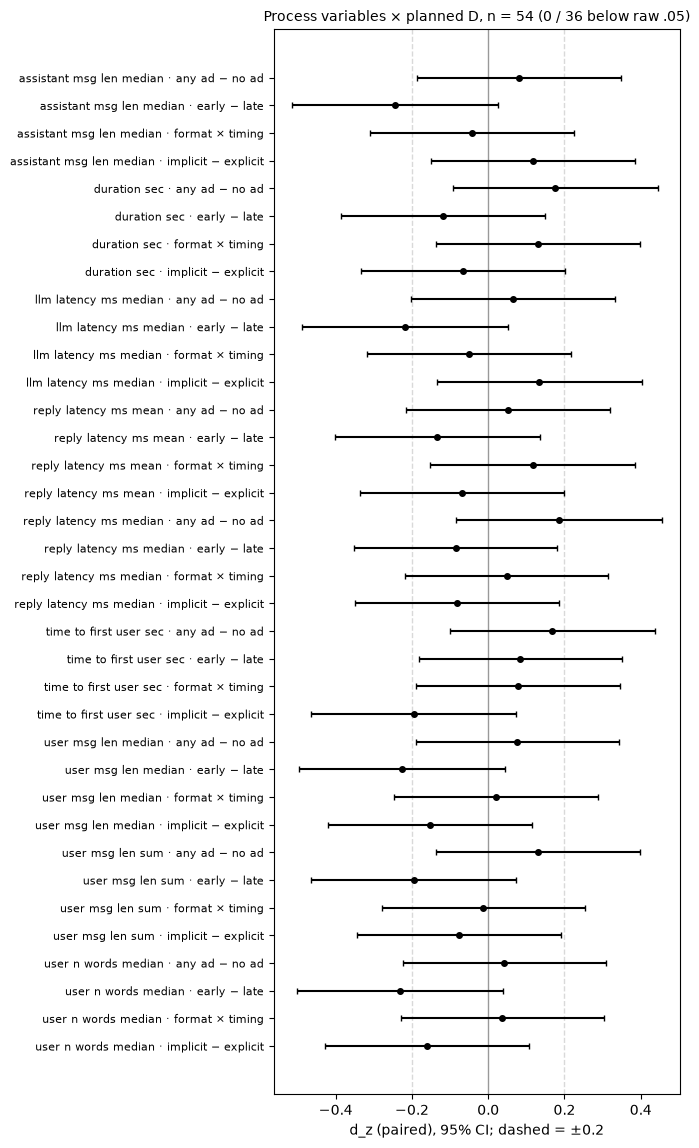

,outcome,test_label,mean,ci95_lo,ci95_hi,dz,p_raw,p_holm_family
0,assistant_msg_len_median,any ad − no ad,66.030,-153.663,285.723,0.080,0.558,1.000
1,assistant_msg_len_median,early − late,-154.745,-324.028,14.538,-0.244,0.079,0.316
2,assistant_msg_len_median,format × timing,-27.181,-198.034,143.673,-0.042,0.756,1.000
3,assistant_msg_len_median,implicit − explicit,79.162,-102.114,260.438,0.116,0.396,1.000
4,duration_sec,any ad − no ad,21.519,-11.014,54.051,0.176,0.200,0.802
5,duration_sec,early − late,-12.643,-40.851,15.566,-0.120,0.384,1.000
6,duration_sec,format × timing,14.328,-14.865,43.522,0.131,0.340,1.000
7,duration_sec,implicit − explicit,-10.515,-52.833,31.802,-0.066,0.628,1.000
8,llm_latency_ms_median,any ad − no ad,140.791,-440.861,722.443,0.065,0.637,1.000
9,llm_latency_ms_median,early − late,-369.055,-822.026,83.916,-0.217,0.116,0.465


In [10]:
import sys
sys.path.insert(0, str(Path.cwd().parent))
import viz
import matplotlib.pyplot as plt
sw = pd.read_csv(EDA.parent / "exploratory" / "sweep_all_tests.csv")
proc = sw[(sw.block == "planned_D") & (sw.tier == "process")].sort_values(["outcome", "test"])
display(viz.forest_dz(proc, "Process variables × planned D, n = 54 (0 / 36 below raw .05)", sig_col="sig_holm_family")); plt.close()
display(proc[["outcome", "test_label", "mean", "ci95_lo", "ci95_hi", "dz", "p_raw", "p_holm_family"]].round(3).reset_index(drop=True))